# Redundancy Analysis (RDA)

## Overview
RDA is a **linear constrained ordination** method: it finds the ordination of a multivariate response matrix (Y) that is maximally explained by a set of environmental predictors (X). It is the constrained extension of PCA, just as CCA is the constrained extension of CA.

| Method | Response type | Constraint | Distance assumed |
|---|---|---|---|
| PCA | Continuous (linear) | None (unconstrained) | Euclidean |
| **RDA** | Continuous (linear) | Environmental predictors | Euclidean |
| CA | Counts (unimodal) | None | Chi-square |
| CCA | Counts (unimodal) | Environmental predictors | Chi-square |
| dbRDA | Any (via distance) | Environmental predictors | Any (Bray-Curtis, Jaccard…) |

**When to use RDA vs dbRDA:** RDA operates on the raw species matrix and assumes linear species responses. Use RDA for physical/chemical multivariate responses, transformed species data (Hellinger, log), or when Euclidean distances are ecologically meaningful. Use dbRDA (already in this library) when you want to constrain ordination based on non-Euclidean dissimilarities.

**Reference:** Quinn & Keough (2002) ch. 17

---

In [1]:
library(tidyverse); library(vegan)
set.seed(19)
# Benthic invertebrate community (Hellinger-transformed) across 40 sites
# 8 species, 4 environmental variables
n <- 40
env <- data.frame(
  temperature  = runif(n, 10, 22),
  salinity     = runif(n, 20, 35),
  depth        = runif(n, 2, 30),
  organics     = runif(n, 0.5, 8)
)
# Species abundances driven partly by environment
build_sp <- function(env_combo, noise = 1.5)
  round(exp(2 + env_combo + rnorm(n, 0, noise))) |> pmax(0L)

sp <- data.frame(
  capitella   = build_sp( 0.08 * env$organics - 0.05 * env$depth),
  hediste     = build_sp( 0.06 * env$organics),
  mya         = build_sp(-0.04 * env$temperature + 0.03 * env$salinity),
  cerastoderma= build_sp( 0.05 * env$salinity - 0.03 * env$depth),
  nephrops    = build_sp( 0.07 * env$depth),
  crangon     = build_sp(-0.03 * env$organics + 0.04 * env$depth),
  arenicola   = build_sp( 0.06 * env$organics - 0.02 * env$temperature),
  corophium   = build_sp( 0.04 * env$organics)
)

# Hellinger transformation (sqrt of relative abundance): linearises species-environment
sp_hel <- decostand(sp, method = "hellinger")
cat("Dimensions: sites =", nrow(sp), ", species =", ncol(sp),
    ", env vars =", ncol(env), "\n")

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'vegan' was built under R version 4.4.3"
Loading required package: permute



Dimensions: sites = 40 , species = 8 , env vars = 4 


---
## Fit RDA and examine results

In [2]:
# Full RDA: all environmental variables
rda_full <- rda(sp_hel ~ temperature + salinity + depth + organics,
                data = env)
cat("=== RDA Summary ===\n")
print(summary(rda_full, display = NULL))  # axis eigenvalues and R2

# R² and adjusted R²
r2     <- RsquareAdj(rda_full)$r.squared
r2_adj <- RsquareAdj(rda_full)$adj.r.squared
cat(sprintf("\nR² = %.3f, Adjusted R² = %.3f\n", r2, r2_adj))
cat("(Adjusted R² accounts for number of predictors — prefer this)\n")

=== RDA Summary ===

Call:
rda(formula = sp_hel ~ temperature + salinity + depth + organics,      data = env) 

Partitioning of variance:
              Inertia Proportion
Total         0.33815     1.0000
Constrained   0.04822     0.1426
Unconstrained 0.28993     0.8574

Eigenvalues, and their contribution to the variance 

Importance of components:
                         RDA1    RDA2     RDA3     RDA4     PC1     PC2     PC3
Eigenvalue            0.02674 0.01184 0.007987 0.001648 0.06669 0.05356 0.05173
Proportion Explained  0.07909 0.03501 0.023619 0.004872 0.19722 0.15838 0.15299
Cumulative Proportion 0.07909 0.11410 0.137719 0.142591 0.33981 0.49819 0.65118
                          PC4     PC5     PC6     PC7      PC8
Eigenvalue            0.03901 0.03138 0.02855 0.01605 0.002973
Proportion Explained  0.11535 0.09279 0.08443 0.04746 0.008792
Cumulative Proportion 0.76653 0.85932 0.94375 0.99121 1.000000

Accumulated constrained eigenvalues
Importance of components:
              

In [3]:
# Permutation test for overall model and each axis
cat("--- Global permutation test (999 permutations) ---\n")
print(anova.cca(rda_full, permutations = 999))

cat("\n--- Axis-by-axis permutation tests ---\n")
print(anova.cca(rda_full, by = "axis", permutations = 999))

cat("\n--- Term-by-term (marginal) tests ---\n")
print(anova.cca(rda_full, by = "margin", permutations = 999))

--- Global permutation test (999 permutations) ---
Permutation test for rda under reduced model
Permutation: free
Number of permutations: 999

Model: rda(formula = sp_hel ~ temperature + salinity + depth + organics, data = env)
         Df Variance      F Pr(>F)  
Model     4 0.048217 1.4552  0.075 .
Residual 35 0.289935                
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

--- Axis-by-axis permutation tests ---
Permutation test for rda under reduced model
Forward tests for axes
Permutation: free
Number of permutations: 999

Model: rda(formula = sp_hel ~ temperature + salinity + depth + organics, data = env)
         Df Variance      F Pr(>F)  
RDA1      1 0.026743 3.2283  0.057 .
RDA2      1 0.011840 1.4701  0.631  
RDA3      1 0.007987 1.0192  0.738  
RDA4      1 0.001648 0.2159  0.986  
Residual 35 0.289935                
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

--- Term-by-term (marginal) tests ---
Permutation test for rda u

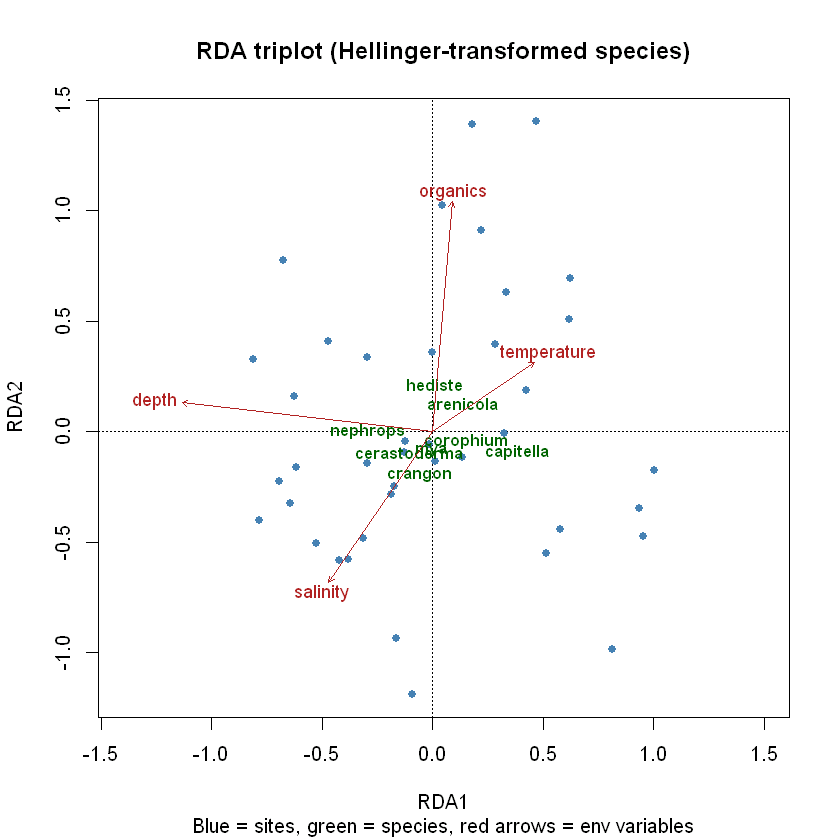

In [4]:
# Triplot: sites, species, and environmental arrows
plot(rda_full, type = "n", main = "RDA triplot (Hellinger-transformed species)")
points(rda_full, display = "sites", pch = 16, col = "steelblue", cex = 0.9)
text(rda_full, display = "species", col = "darkgreen", cex = 0.85, font = 2)
text(rda_full, display = "bp", col = "firebrick", cex = 0.9,
     arrow.mul = 0.9)
title(sub = "Blue = sites, green = species, red arrows = env variables")

---
## Variance partitioning

--- Variance partitioning: physical vs chemical environment ---

Partition of variance in RDA 

Call: varpart(Y = sp_hel, X = ~temperature + depth, ~salinity +
organics, data = env)

Explanatory tables:
X1:  ~temperature + depth
X2:  ~salinity + organics 

No. of explanatory tables: 2 
Total variation (SS): 13.188 
            Variance: 0.33815 
No. of observations: 40 

Partition table:
                     Df R.squared Adj.R.squared Testable
[a+c] = X1            2   0.09475       0.04582     TRUE
[b+c] = X2            2   0.05494       0.00386     TRUE
[a+b+c] = X1+X2       4   0.14259       0.04460     TRUE
Individual fractions                                    
[a] = X1|X2           2                 0.04074     TRUE
[b] = X2|X1           2                -0.00122     TRUE
[c]                   0                 0.00507    FALSE
[d] = Residuals                         0.95540    FALSE
---
Use function 'rda' to test significance of fractions of interest


Warning message in mtext(...):
""alpha" is not a graphical parameter"



Note: fractions can be negative (spurious correlation between sets)
Only testable fractions [a] and [c] can be significance-tested via RDA


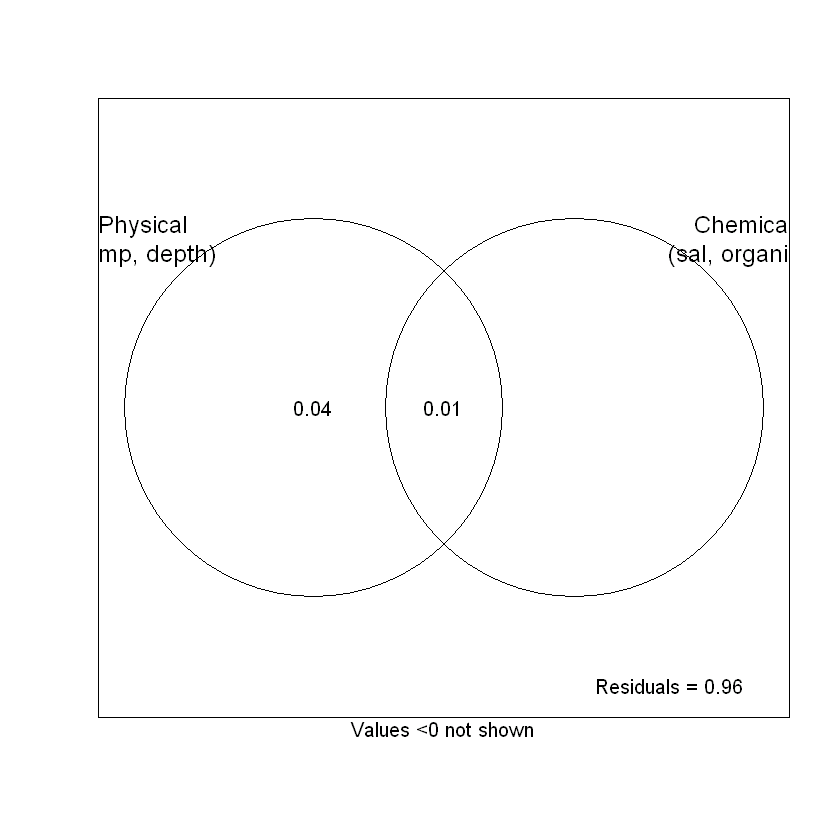

In [5]:
# Partition variance between two predictor sets:
# Set 1: abiotic physical (temperature, depth)
# Set 2: chemical (salinity, organics)
cat("--- Variance partitioning: physical vs chemical environment ---\n")
vp <- varpart(sp_hel,
              ~ temperature + depth,
              ~ salinity + organics,
              data = env)
print(vp)
plot(vp, Xnames = c("Physical\n(temp, depth)", "Chemical\n(sal, organics)"),
     bg = c("#7FBFFF", "#FFB347"), alpha = 0.7,
     main = "Variance partitioning: RDA")
cat("\nNote: fractions can be negative (spurious correlation between sets)\n")
cat("Only testable fractions [a] and [c] can be significance-tested via RDA\n")

In [6]:
# Forward selection to identify parsimonious model
# Blanchet et al. (2008): stop when R2_adj > full model R2_adj OR p > alpha
cat("--- Forward selection (ordiR2step) ---\n")
rda_null <- rda(sp_hel ~ 1, data = env)  # intercept-only model
rda_fwd  <- ordiR2step(rda_null,
                        scope = formula(rda_full),
                        direction = "forward",
                        R2scope = TRUE,
                        permutations = 999,
                        trace = FALSE)
cat("Selected model:\n")
print(rda_fwd$call)
cat("\nAdjusted R² of selected model:",
    round(RsquareAdj(rda_fwd)$adj.r.squared, 3), "\n")

--- Forward selection (ordiR2step) ---
Selected model:
rda(formula = sp_hel ~ depth, data = env)

Adjusted R² of selected model: 0.044 


---
## Common Pitfalls

**1. Using raw species abundances without transformation**
RDA is based on Euclidean distances, which are dominated by the most abundant species. Apply Hellinger (sqrt of relative abundance), log(y+1), or chord transformation before RDA to downweight dominant species and improve linearity. The Hellinger transformation is generally recommended for species data.

**2. Confusing RDA with dbRDA**
dbRDA (distance-based RDA, via `vegan::capscale`) starts from a dissimilarity matrix of your choosing (e.g., Bray-Curtis). RDA operates on the raw transformed species matrix. For presence/absence or strongly zero-inflated data, Bray-Curtis-based dbRDA is usually preferable to Hellinger-RDA.

**3. Reporting unadjusted R²**
Like R² in regression, the unadjusted R² from RDA inflates with number of predictors. Always report adjusted R² (via `RsquareAdj()`). With many predictors and few sites, adj-R² can be negative — indicating the model explains less than chance.

**4. Forward selection without an R² stopping criterion**
Standard forward selection (e.g., `add1`) adds variables until p > α but ignores inflation of R². Use `ordiR2step()` with `R2scope = TRUE` (Blanchet et al. 2008), which stops when adj-R² of the current model exceeds that of the full model.

**5. Testing terms by axis rather than margin when predictors are correlated**
Using `by = "axis"` tests sequential RDA axes, which are ordered by amount of variance explained. Use `by = "margin"` (analogous to Type III SS in ANOVA) for the independent contribution of each predictor.

**6. Interpreting arrow direction in triplots without accounting for axis scaling**
RDA triplots can use different scaling options (scaling 1 = site distances, scaling 2 = species-environment correlations). Species arrows point toward high values of that species; environment arrows point toward increasing values. Angles between arrows approximate correlations only in scaling 2.


---
*r_methods_library - Samantha McGarrigle*